# MLP and CNN experiment report

This notebook loads the saved JSON files from `results/` and keeps the MLP and CNN experiments separate. Plot titles and summary tables include the architecture, dataset, and run id so it is clear which experiment produced each curve.


In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


RESULTS_DIR = Path("results")
result_paths = sorted(RESULTS_DIR.glob("*.json"))

result_paths


[WindowsPath('results/cnn_cifar10_20260511_124835.json'),
 WindowsPath('results/cnn_cifar10_20260511_174226.json'),
 WindowsPath('results/cnn_fashionmnist_20260511_122614.json'),
 WindowsPath('results/cnn_fashionmnist_20260511_162637.json'),
 WindowsPath('results/cnn_mnist_20260511_120918.json'),
 WindowsPath('results/cnn_mnist_20260511_170059.json'),
 WindowsPath('results/mlp_cifar10_20260511_132119.json'),
 WindowsPath('results/mlp_cifar10_20260511_153145.json'),
 WindowsPath('results/mlp_fashionmnist_20260511_130647.json'),
 WindowsPath('results/mlp_fashionmnist_20260511_145812.json'),
 WindowsPath('results/mlp_mnist_20260511_125754.json'),
 WindowsPath('results/mlp_mnist_20260511_155205.json')]

## Load and organize results


In [2]:
METHOD_LABELS = {
    "mono_ff": "MonoFWD FF",
    "mono_bp": "MonoFWD BP",
    "bp": "Backprop",
}

MODEL_LABELS = {
    "mlp": "MLP",
    "cnn": "CNN",
}

DATASET_LABELS = {
    "mnist": "MNIST",
    "fashionmnist": "Fashion-MNIST",
    "cifar10": "CIFAR-10",
    "cifar100": "CIFAR-100",
}


def parse_result_filename(path: Path) -> tuple[str, str, str]:
    model, dataset, *run_parts = path.stem.split("_")
    return model, dataset, "_".join(run_parts)


def load_experiment_history(path: Path) -> pd.DataFrame:
    with path.open() as f:
        raw = json.load(f)

    model, dataset, run_id = parse_result_filename(path)
    model_label = MODEL_LABELS.get(model, model.upper())
    dataset_label = DATASET_LABELS.get(dataset, dataset.upper())

    rows = []
    for method, metrics in raw.items():
        if method not in METHOD_LABELS:
            continue

        max_train_epoch = len(metrics.get("train_losses", []))
        for metric, values in metrics.items():
            if not isinstance(values, list):
                continue

            is_final_test_metric = metric.startswith("test_") and len(values) == 1
            for index, value in enumerate(values, start=1):
                epoch = max_train_epoch if is_final_test_metric else index
                rows.append(
                    {
                        "file": path.name,
                        "model": model,
                        "model_label": model_label,
                        "dataset": dataset,
                        "dataset_label": dataset_label,
                        "run_id": run_id,
                        "experiment": f"{model_label} / {dataset_label} / {run_id}",
                        "method": method,
                        "method_label": METHOD_LABELS[method],
                        "metric": metric,
                        "epoch": epoch,
                        "value": value,
                        "is_final_test": is_final_test_metric,
                    }
                )

    return pd.DataFrame(rows)


history = pd.concat(
    [load_experiment_history(path) for path in result_paths],
    ignore_index=True,
)

losses = (
    history[history["metric"].isin(["train_losses", "val_losses", "test_losses"])]
    .copy()
    .assign(split=lambda df: df["metric"].str.replace("_losses", "", regex=False))
)

accuracies = (
    history[history["metric"].isin(["train_accs", "val_accs", "test_accs"])]
    .copy()
    .assign(split=lambda df: df["metric"].str.replace("_accs", "", regex=False))
)

display(losses.head())
display(
    history[history["metric"].str.startswith("train_")]
    .groupby(["model_label", "dataset_label", "run_id", "method_label"])["epoch"]
    .max()
    .rename("trained_epochs")
    .to_frame()
)


,file,model,model_label,dataset,dataset_label,run_id,experiment,method,method_label,metric,epoch,value,is_final_test,split
0,cnn_cifar10_20260511_124835.json,cnn,CNN,cifar10,CIFAR-10,20260511_124835,CNN / CIFAR-10 / 20260511_124835,mono_ff,MonoFWD FF,train_losses,1,2.329503,False,train
1,cnn_cifar10_20260511_124835.json,cnn,CNN,cifar10,CIFAR-10,20260511_124835,CNN / CIFAR-10 / 20260511_124835,mono_ff,MonoFWD FF,train_losses,2,1.922685,False,train
2,cnn_cifar10_20260511_124835.json,cnn,CNN,cifar10,CIFAR-10,20260511_124835,CNN / CIFAR-10 / 20260511_124835,mono_ff,MonoFWD FF,train_losses,3,1.798640,False,train
3,cnn_cifar10_20260511_124835.json,cnn,CNN,cifar10,CIFAR-10,20260511_124835,CNN / CIFAR-10 / 20260511_124835,mono_ff,MonoFWD FF,train_losses,4,1.703425,False,train
4,cnn_cifar10_20260511_124835.json,cnn,CNN,cifar10,CIFAR-10,20260511_124835,CNN / CIFAR-10 / 20260511_124835,mono_ff,MonoFWD FF,train_losses,5,1.641926,False,train


trained_epochs
model_label dataset_label run_id          method_label                
CNN         CIFAR-10      20260511_124835 Backprop                 100
                                          MonoFWD BP               100
                                          MonoFWD FF               100
                          20260511_174226 Backprop                 200
                                          MonoFWD BP               200
                                          MonoFWD FF               200
            Fashion-MNIST 20260511_122614 Backprop                 100
                                          MonoFWD BP               100
                                          MonoFWD FF               100
                          20260511_162637 Backprop                 200
                                          MonoFWD BP               200
                                          MonoFWD FF               200
            MNIST         20260511_120918 Backprop                 100
                                          MonoFWD BP               100
                                          MonoFWD FF               100
                          20260511_170059 Backprop                 200
                                          MonoFWD BP               200
                                          MonoFWD FF               200
MLP         CIFAR-10      20260511_132119 Backprop                 100
                                          MonoFWD BP               100
                                          MonoFWD FF               100
                          20260511_153145 Backprop                 200
                                          MonoFWD BP               200
                                          MonoFWD FF               200
            Fashion-MNIST 20260511_130647 Backprop                 100
                                          MonoFWD BP               100
                                          MonoFWD FF               100
                          20260511_145812 Backprop                 200
                                          MonoFWD BP               200
                                          MonoFWD FF               200
            MNIST         20260511_125754 Backprop                 100
                                          MonoFWD BP               100
                                          MonoFWD FF               100
                          20260511_155205 Backprop                 200
                                          MonoFWD BP               200
                                          MonoFWD FF               200

## Loss curves


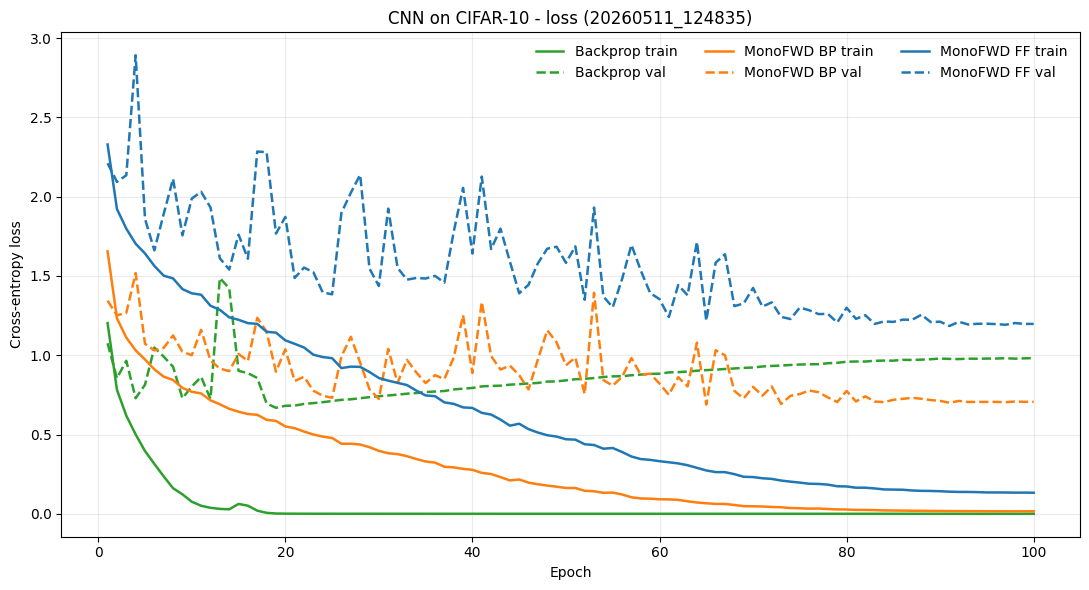

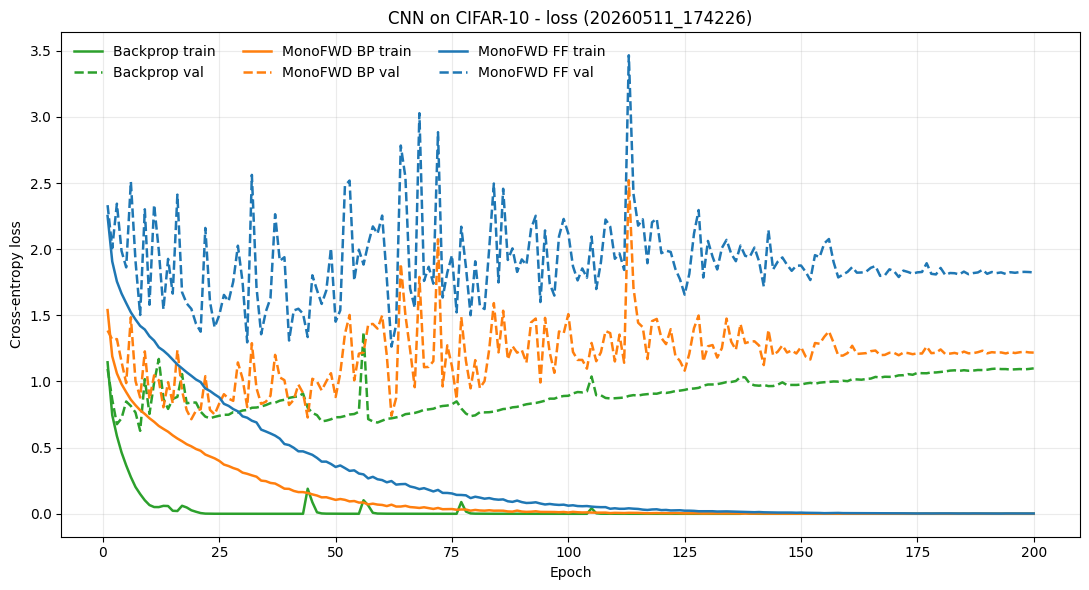

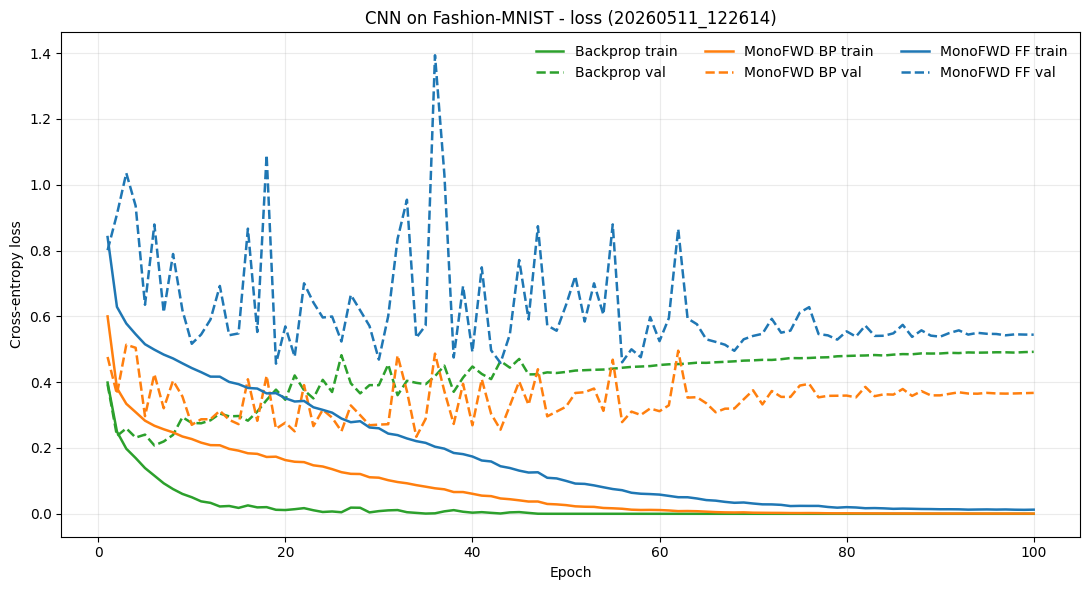

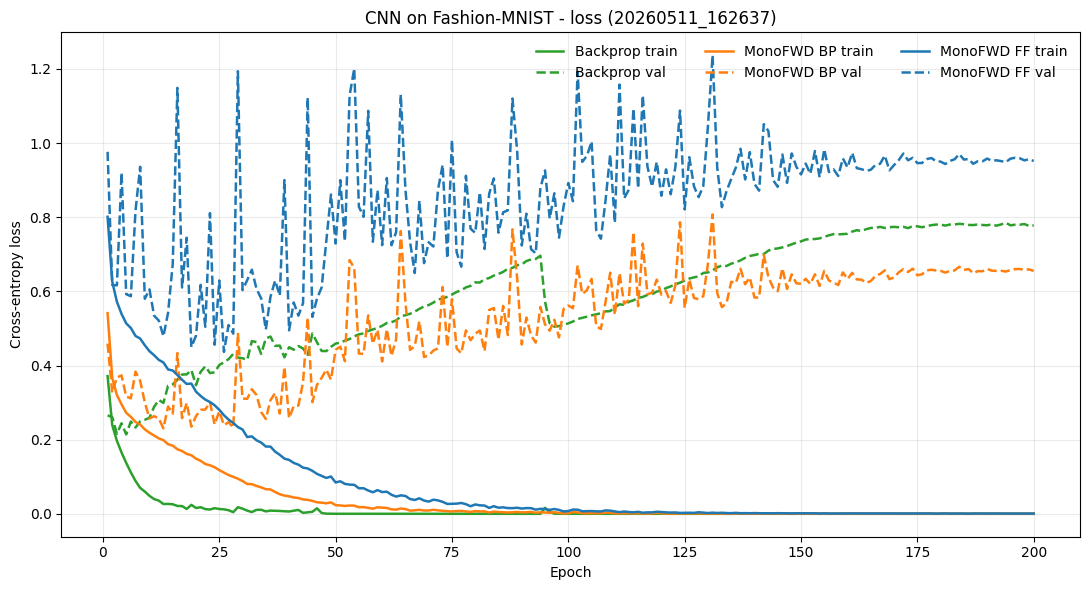

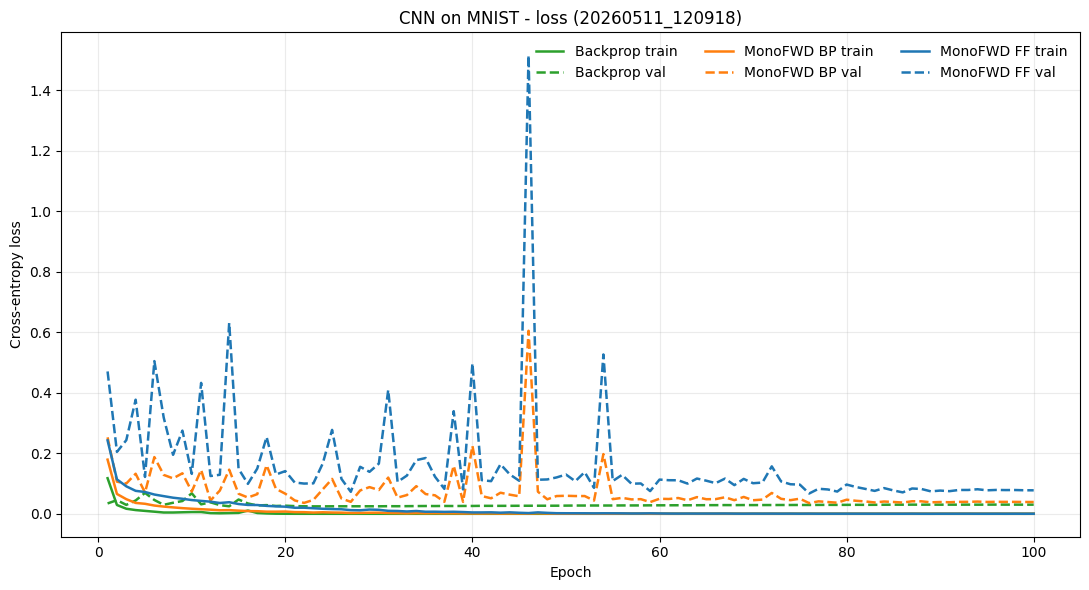

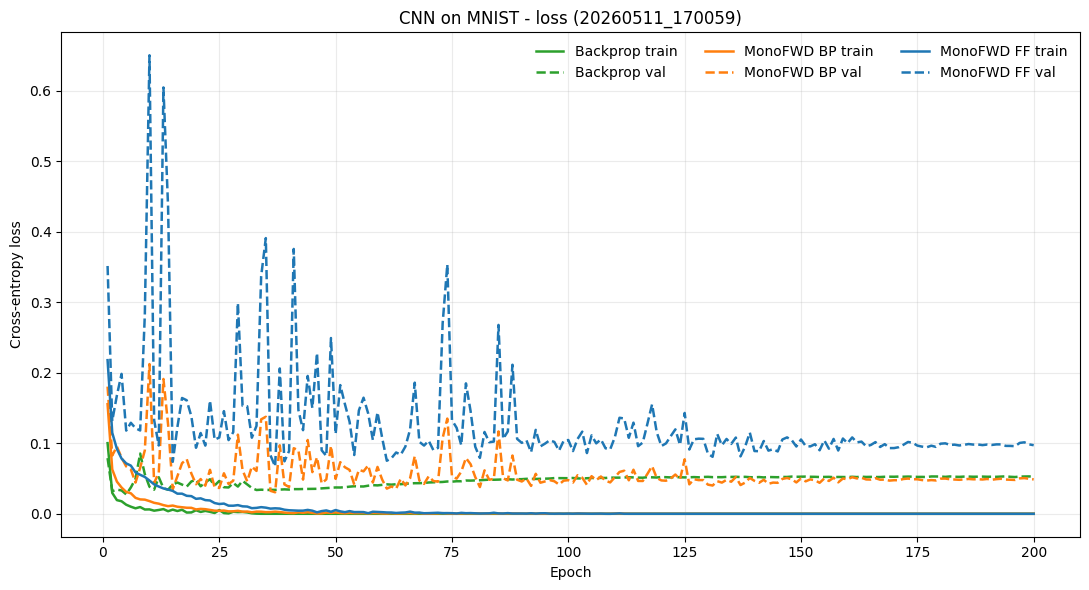

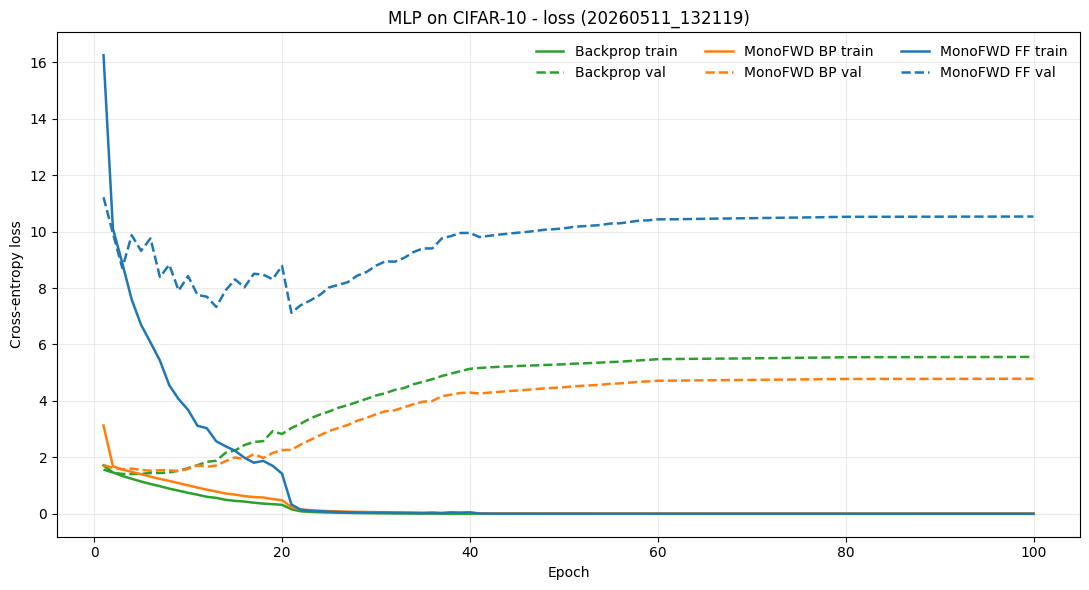

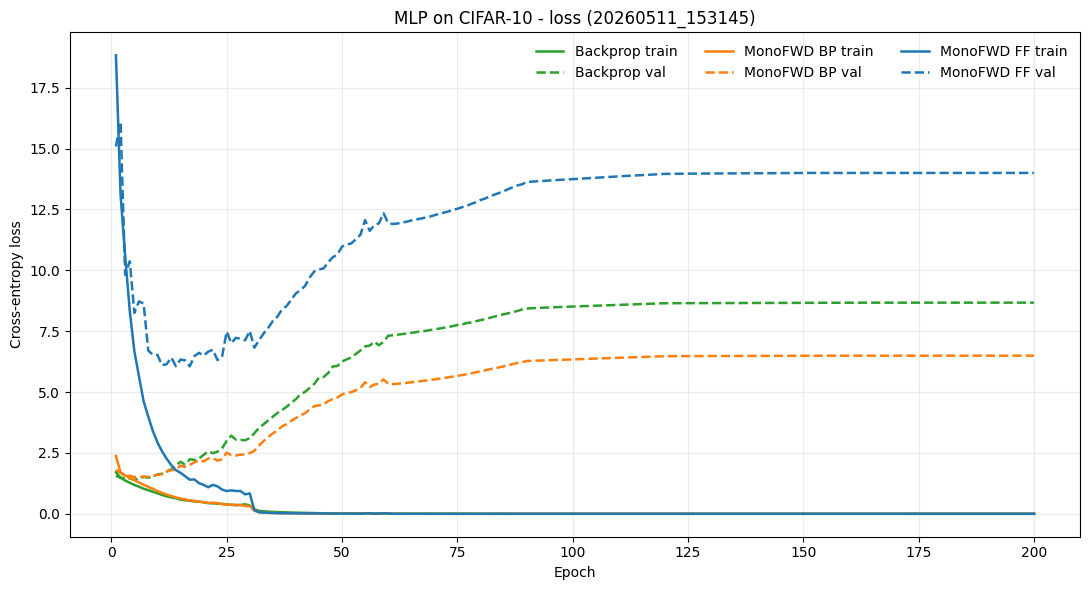

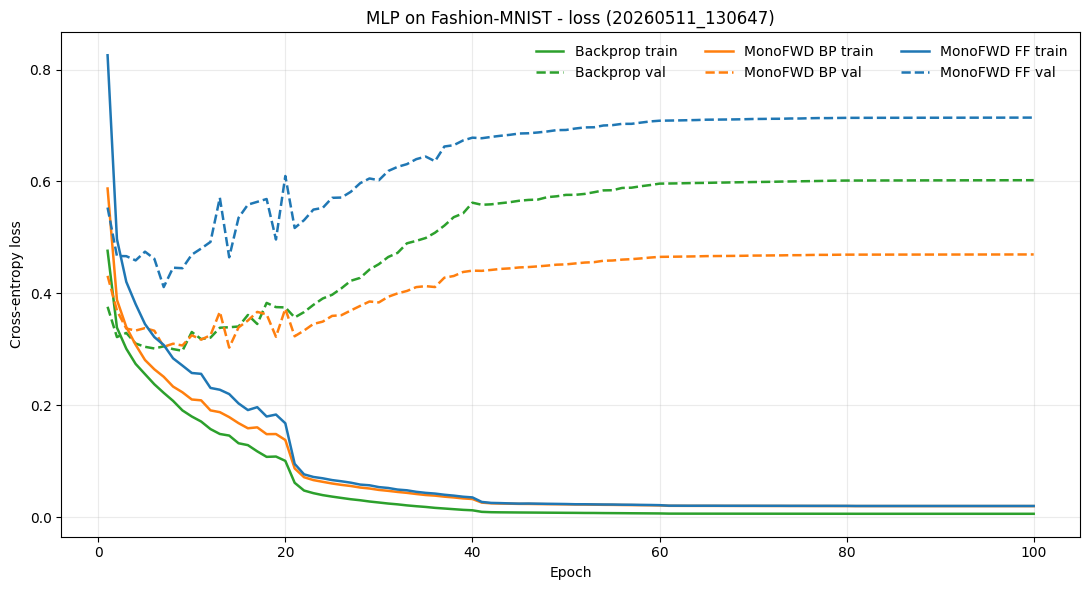

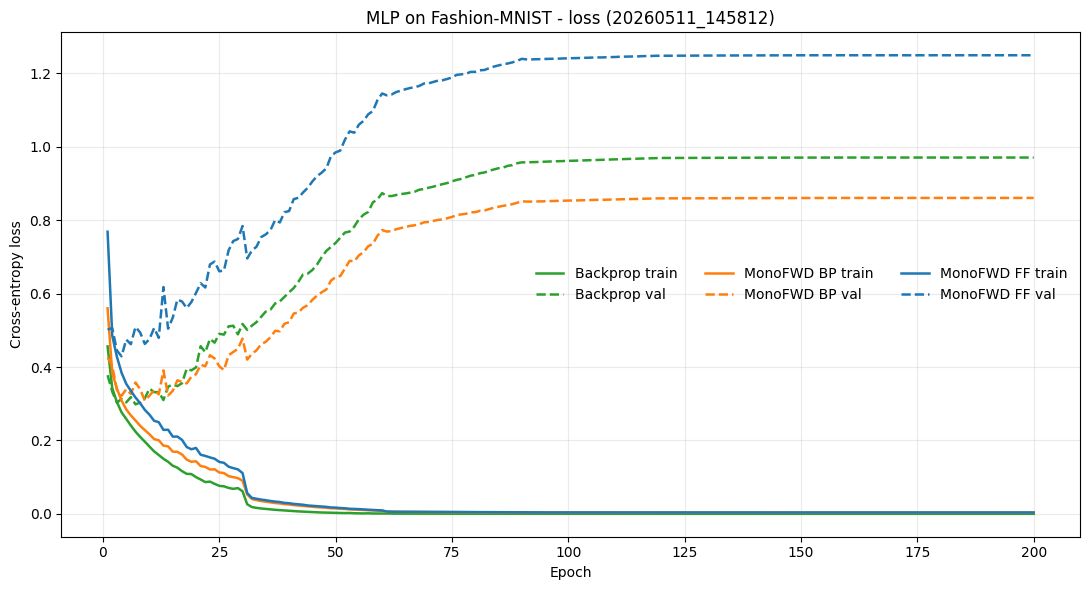

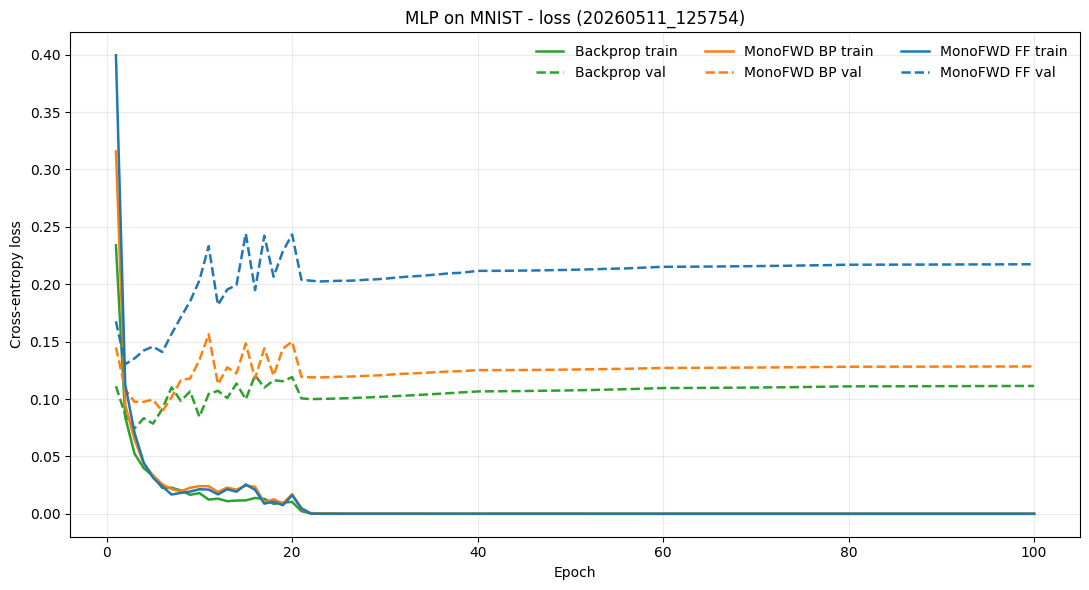

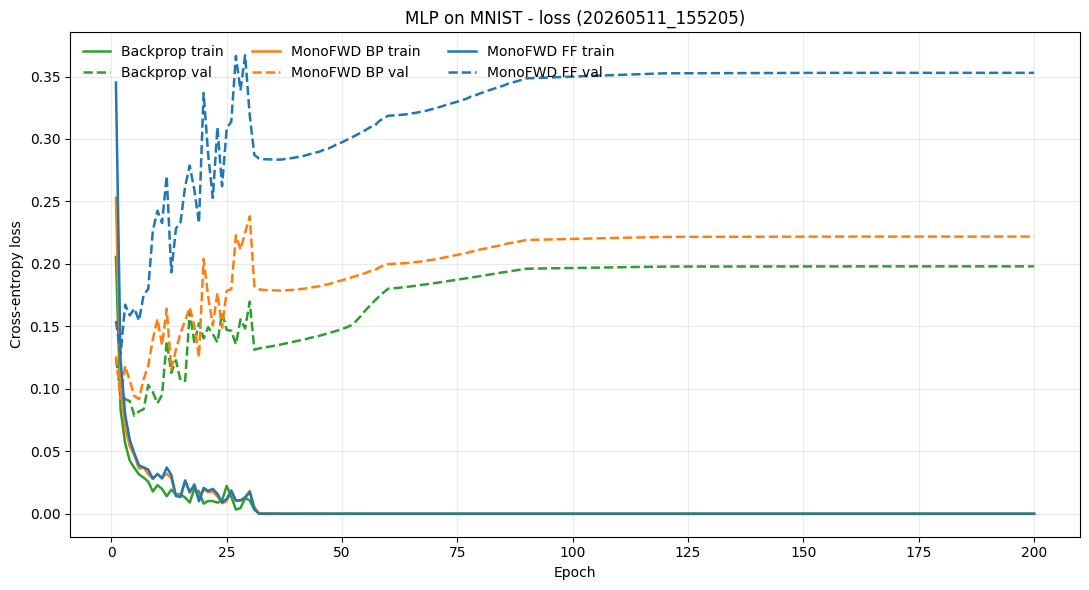

,model_label,dataset_label,run_id,method_label,test_loss
1204,CNN,CIFAR-10,20260511_124835,Backprop,1.011262
802,CNN,CIFAR-10,20260511_124835,MonoFWD BP,0.742836
400,CNN,CIFAR-10,20260511_124835,MonoFWD FF,1.252521
3610,CNN,CIFAR-10,20260511_174226,Backprop,1.192870
2808,CNN,CIFAR-10,20260511_174226,MonoFWD BP,1.265247
2006,CNN,CIFAR-10,20260511_174226,MonoFWD FF,1.938758
4816,CNN,Fashion-MNIST,20260511_122614,Backprop,0.562400
4414,CNN,Fashion-MNIST,20260511_122614,MonoFWD BP,0.456533
4012,CNN,Fashion-MNIST,20260511_122614,MonoFWD FF,0.695393
7222,CNN,Fashion-MNIST,20260511_162637,Backprop,0.860492


In [3]:
method_colors = {
    "MonoFWD FF": "tab:blue",
    "MonoFWD BP": "tab:orange",
    "Backprop": "tab:green",
}
split_styles = {"train": "-", "val": "--", "test": "None"}
split_markers = {"train": None, "val": None, "test": "o"}

loss_groups = losses[losses["split"] != "test"].groupby(
    ["model_label", "dataset_label", "run_id"],
    sort=True,
)

for (model_label, dataset_label, run_id), experiment_losses in loss_groups:
    fig, ax = plt.subplots(figsize=(11, 6))

    for (method_label, split), group in experiment_losses.groupby(
        ["method_label", "split"],
        sort=True,
    ):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            marker=split_markers[split],
            linewidth=1.8,
            label=f"{method_label} {split}",
        )

    ax.set_title(f"{model_label} on {dataset_label} - loss ({run_id})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()

test_loss_summary = (
    losses[losses["split"] == "test"]
    .sort_values(["model_label", "dataset_label", "run_id", "method_label"])[
        ["model_label", "dataset_label", "run_id", "method_label", "value"]
    ]
    .rename(columns={"value": "test_loss"})
)

display(test_loss_summary)


## Accuracy curves


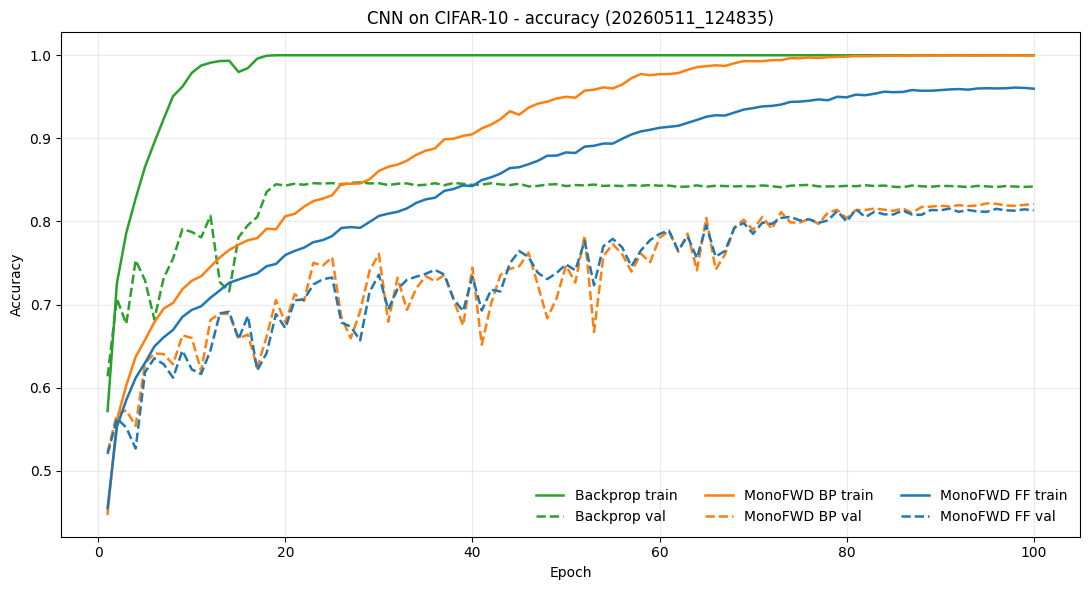

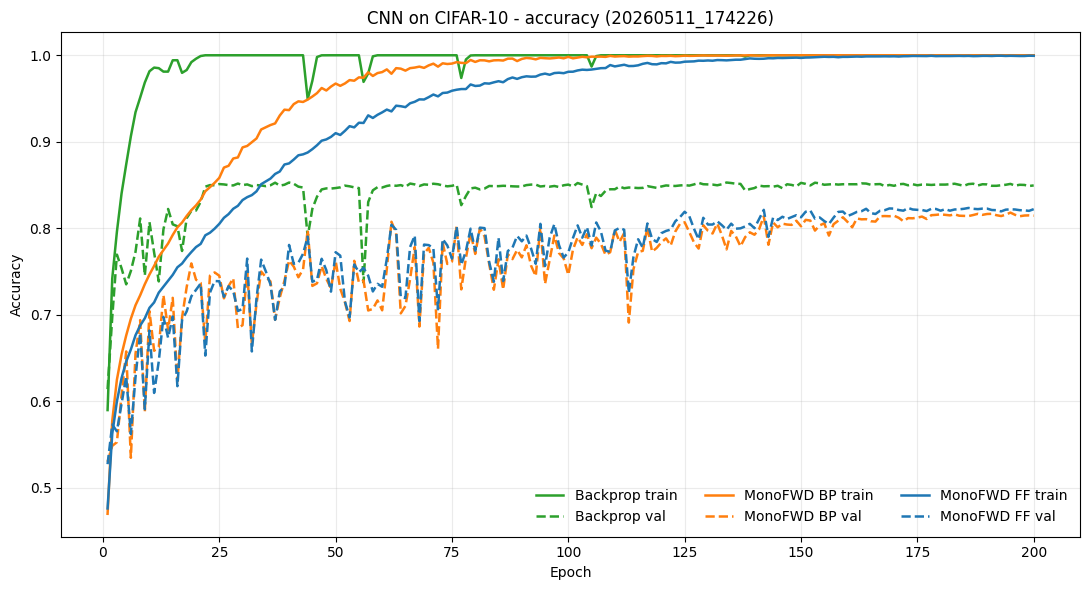

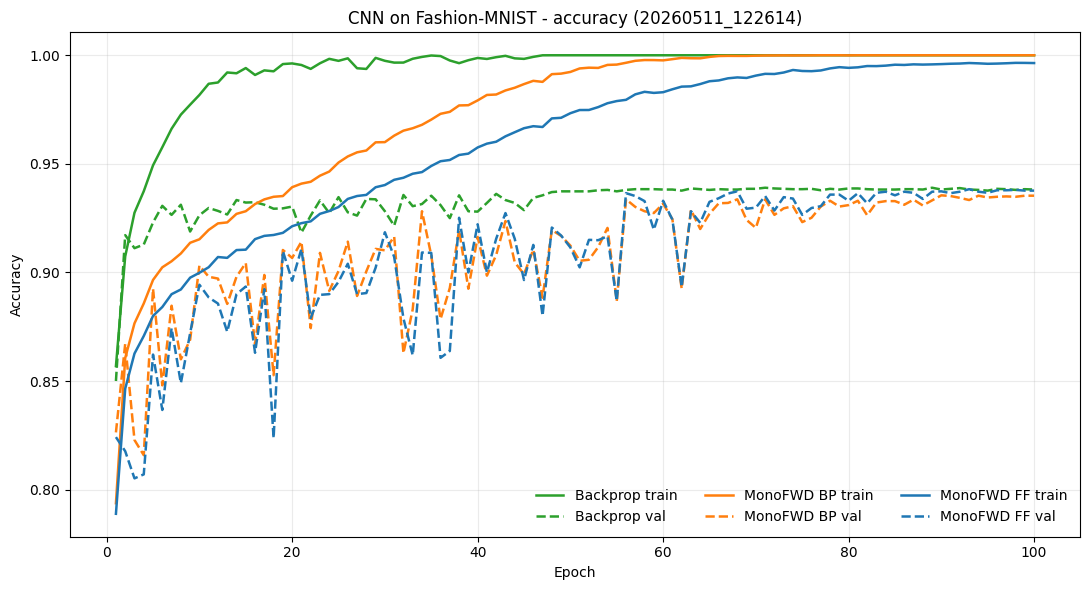

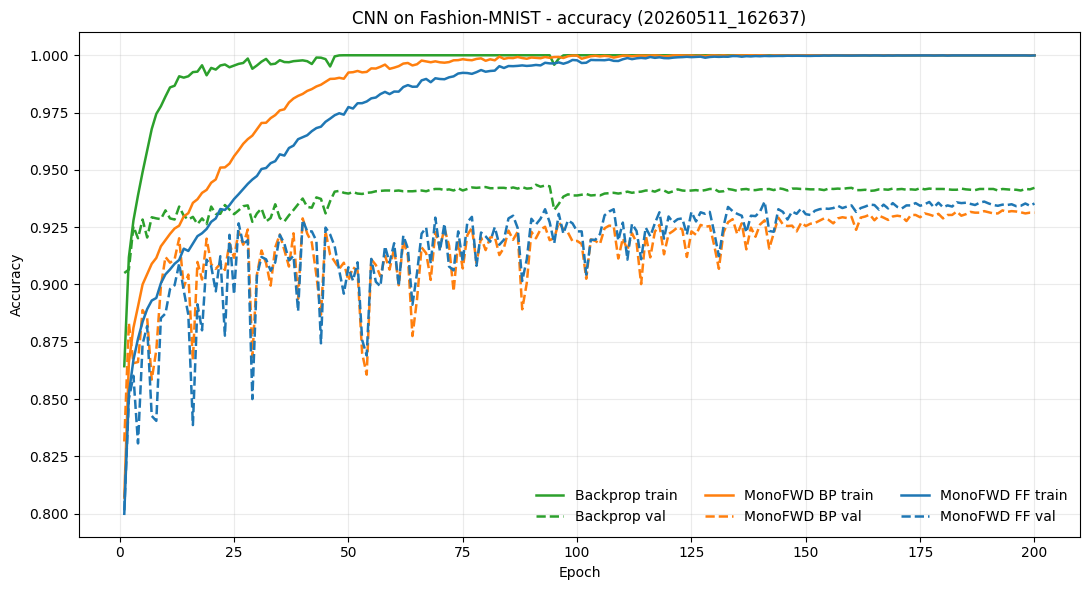

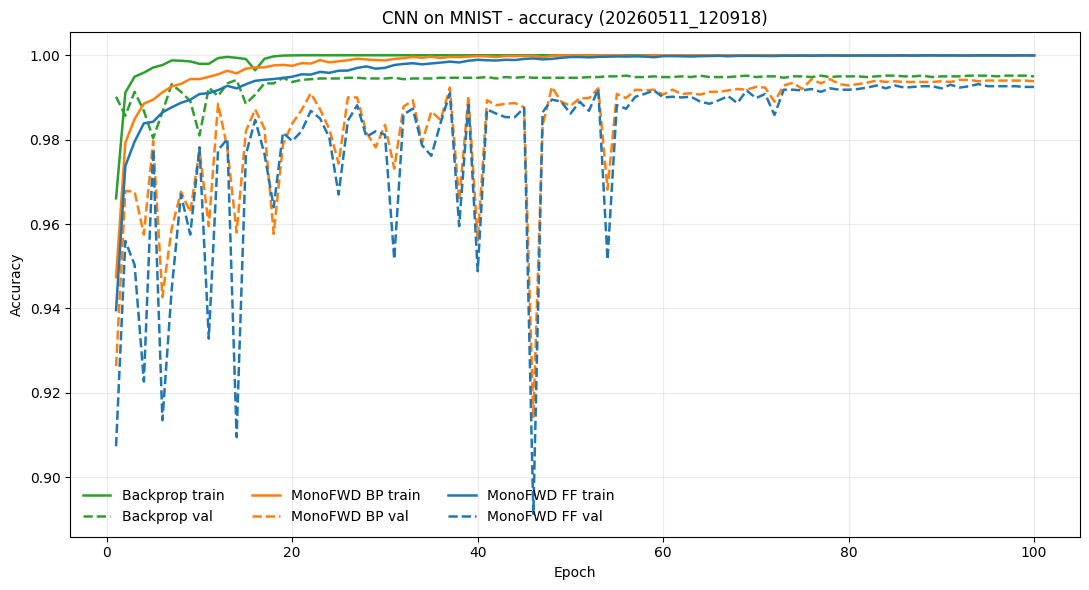

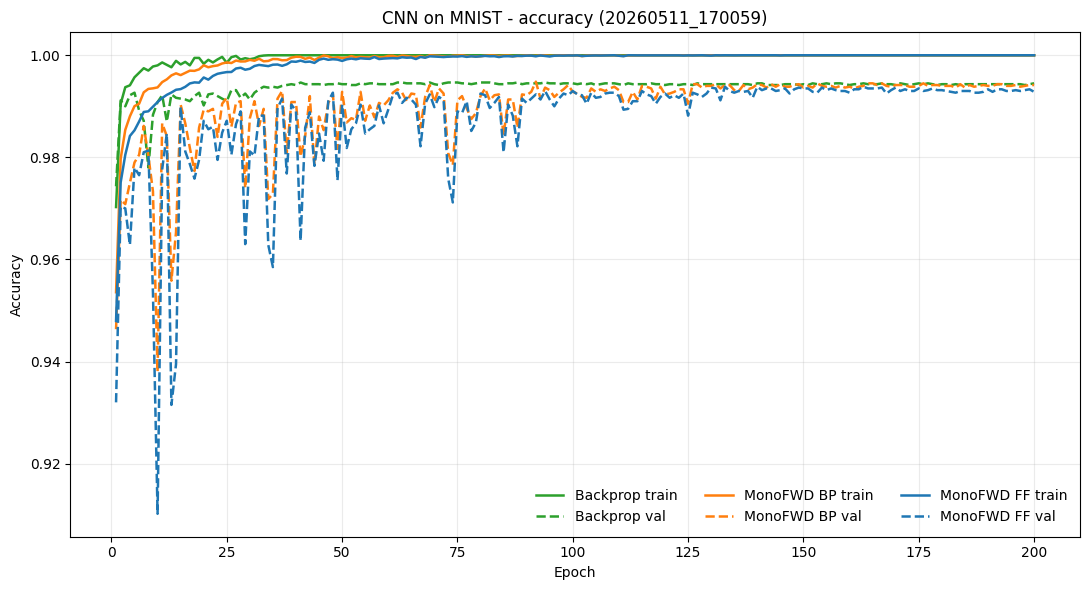

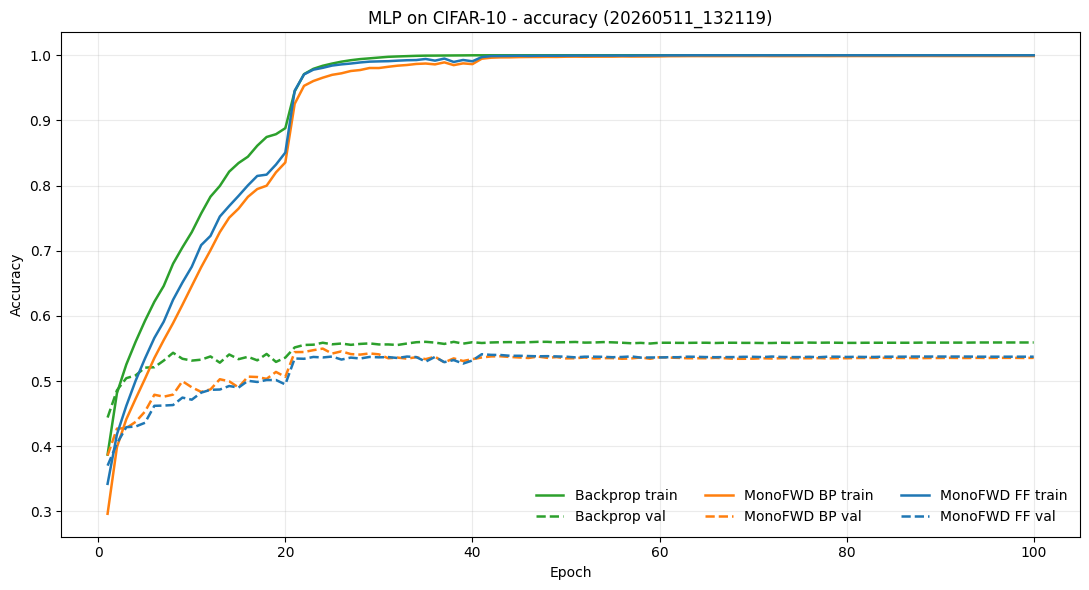

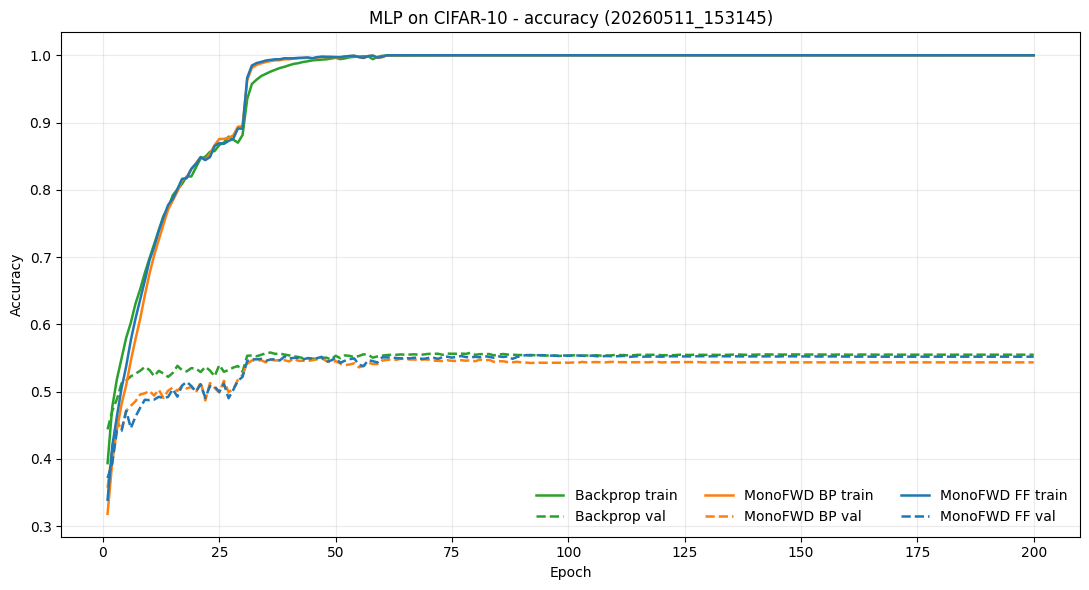

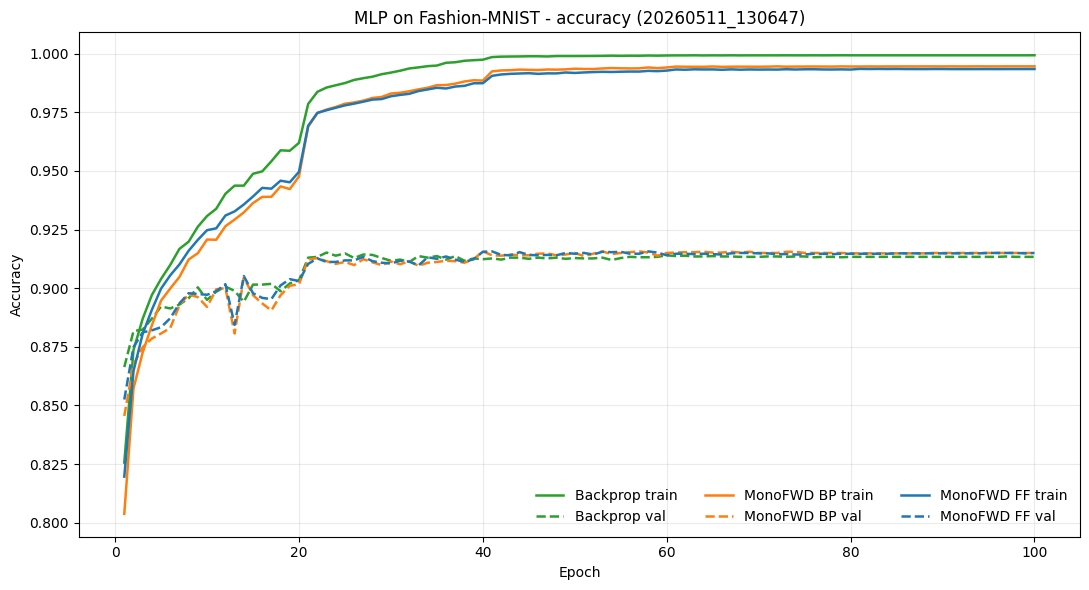

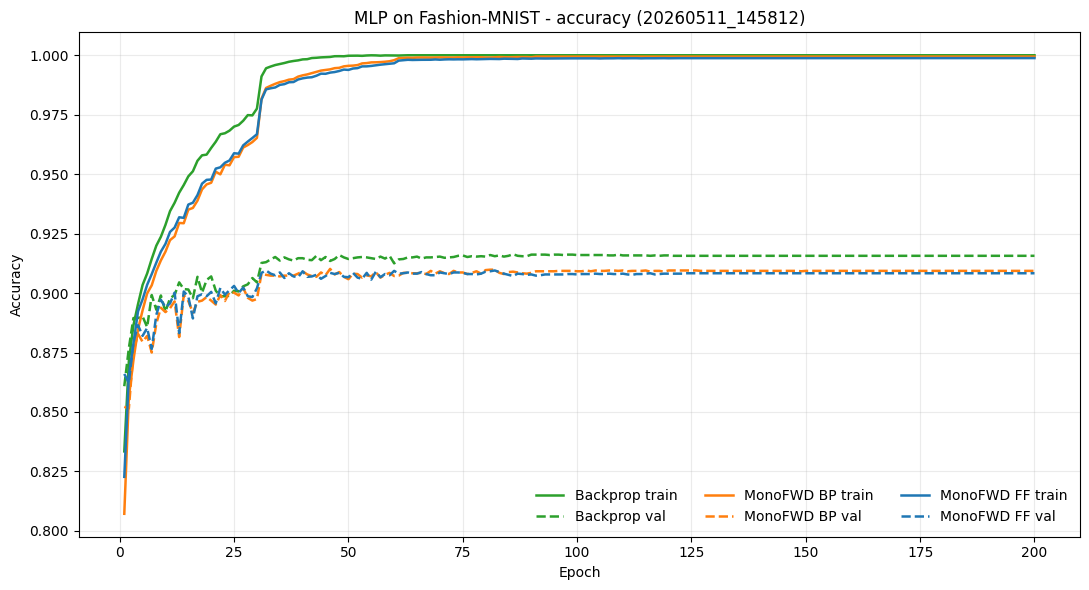

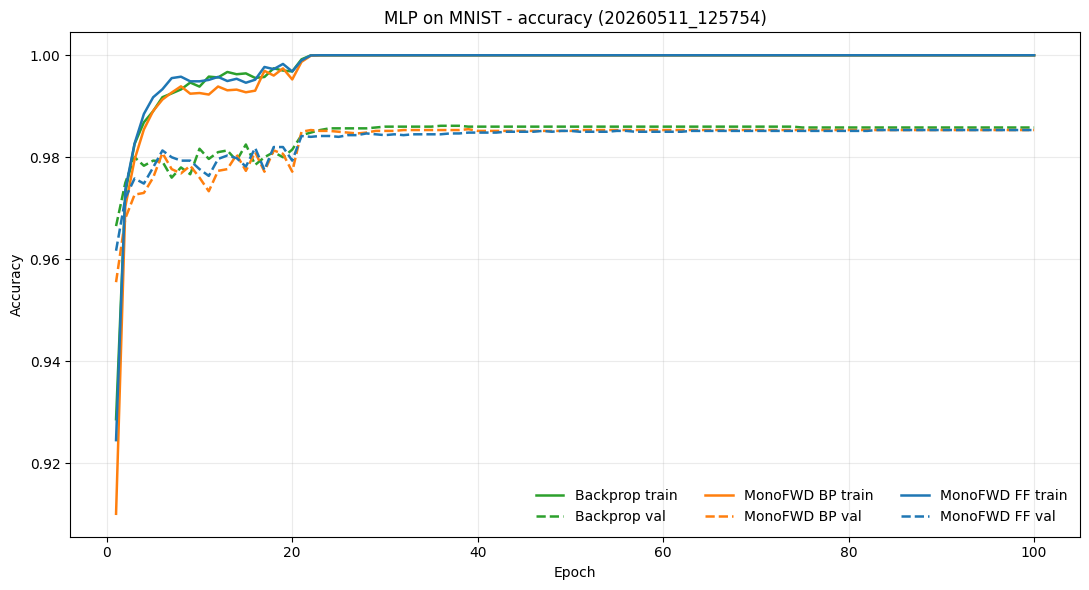

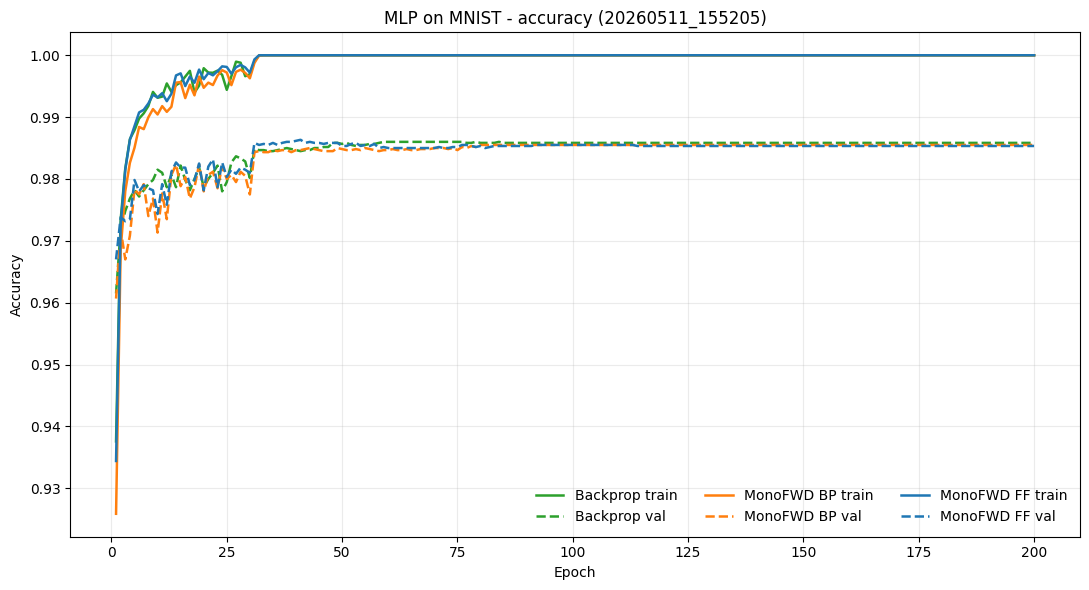

,model_label,dataset_label,run_id,method_label,test_accuracy
1205,CNN,CIFAR-10,20260511_124835,Backprop,0.8352
803,CNN,CIFAR-10,20260511_124835,MonoFWD BP,0.8109
401,CNN,CIFAR-10,20260511_124835,MonoFWD FF,0.8101
3611,CNN,CIFAR-10,20260511_174226,Backprop,0.8391
2809,CNN,CIFAR-10,20260511_174226,MonoFWD BP,0.8061
2007,CNN,CIFAR-10,20260511_174226,MonoFWD FF,0.8151
4817,CNN,Fashion-MNIST,20260511_122614,Backprop,0.9307
4415,CNN,Fashion-MNIST,20260511_122614,MonoFWD BP,0.9198
4013,CNN,Fashion-MNIST,20260511_122614,MonoFWD FF,0.9224
7223,CNN,Fashion-MNIST,20260511_162637,Backprop,0.9318


In [4]:
accuracy_groups = accuracies[accuracies["split"] != "test"].groupby(
    ["model_label", "dataset_label", "run_id"],
    sort=True,
)

for (model_label, dataset_label, run_id), experiment_accuracies in accuracy_groups:
    fig, ax = plt.subplots(figsize=(11, 6))

    for (method_label, split), group in experiment_accuracies.groupby(
        ["method_label", "split"],
        sort=True,
    ):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            marker=split_markers[split],
            linewidth=1.8,
            label=f"{method_label} {split}",
        )

    ax.set_title(f"{model_label} on {dataset_label} - accuracy ({run_id})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()

test_accuracy_summary = (
    accuracies[accuracies["split"] == "test"]
    .sort_values(["model_label", "dataset_label", "run_id", "method_label"])[
        ["model_label", "dataset_label", "run_id", "method_label", "value"]
    ]
    .rename(columns={"value": "test_accuracy"})
)

display(test_accuracy_summary)


## Averaged results across runs


In [5]:
import numpy as np

# Average losses across runs
avg_losses = (
    losses[losses["split"] != "test"]
    .groupby(
        ["model_label", "dataset_label", "method_label", "split", "epoch"],
        as_index=False,
    )
    .agg(
        value_mean=("value", "mean"),
        value_std=("value", "std"),
        count=("value", "count"),
    )
)

# Average accuracies across runs
avg_accuracies = (
    accuracies[accuracies["split"] != "test"]
    .groupby(
        ["model_label", "dataset_label", "method_label", "split", "epoch"],
        as_index=False,
    )
    .agg(
        value_mean=("value", "mean"),
        value_std=("value", "std"),
        count=("value", "count"),
    )
)

avg_losses

,model_label,dataset_label,method_label,split,epoch,value_mean,value_std,count
0,CNN,CIFAR-10,Backprop,train,1,1.174128,0.041019,2
1,CNN,CIFAR-10,Backprop,train,2,0.764066,0.025951,2
2,CNN,CIFAR-10,Backprop,train,3,0.603693,0.021794,2
3,CNN,CIFAR-10,Backprop,train,4,0.482288,0.025900,2
4,CNN,CIFAR-10,Backprop,train,5,0.380682,0.021511,2
...,...,...,...,...,...,...,...,...
7195,MLP,MNIST,MonoFWD FF,val,196,0.352928,NaN,1
7196,MLP,MNIST,MonoFWD FF,val,197,0.352928,NaN,1
7197,MLP,MNIST,MonoFWD FF,val,198,0.352928,NaN,1
7198,MLP,MNIST,MonoFWD FF,val,199,0.352928,NaN,1


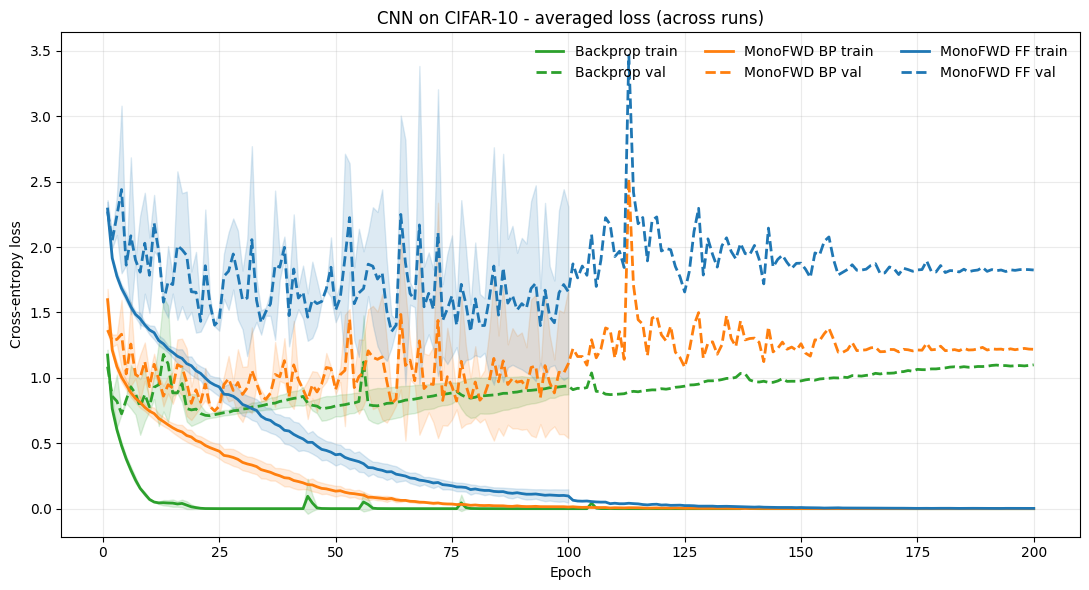

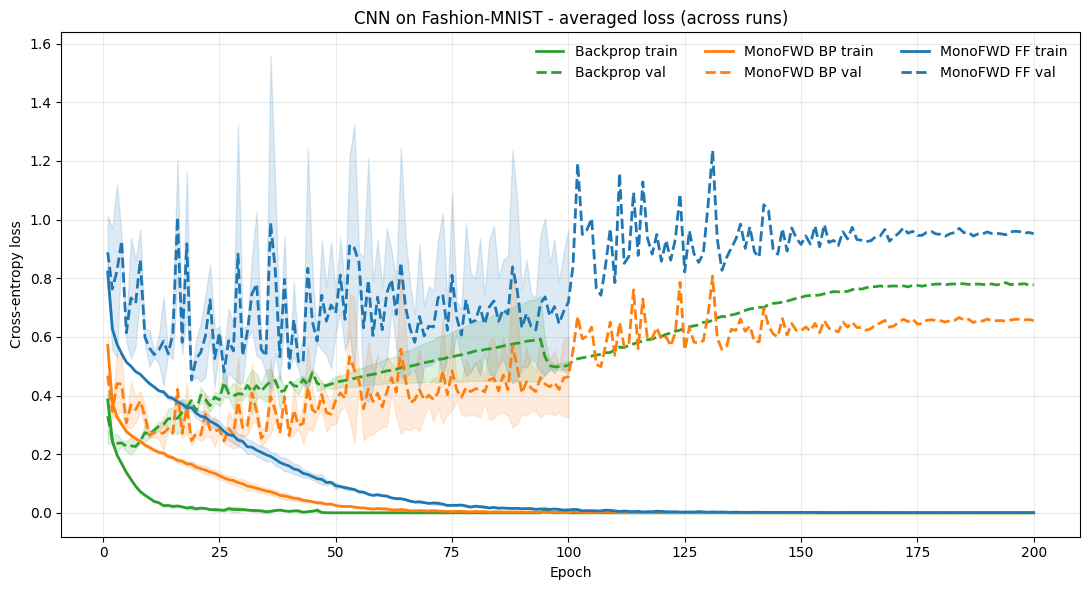

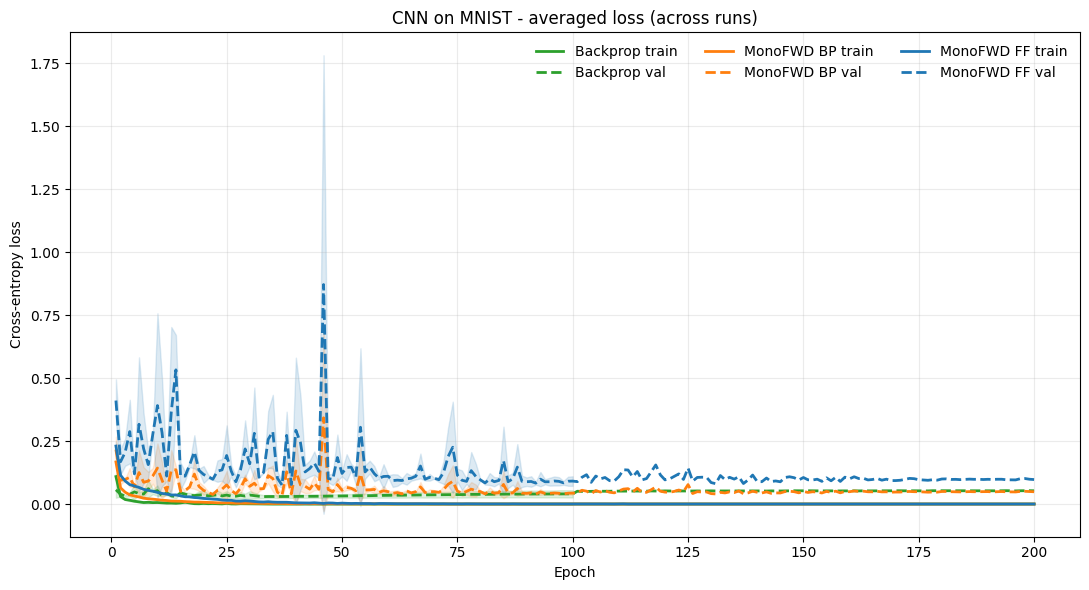

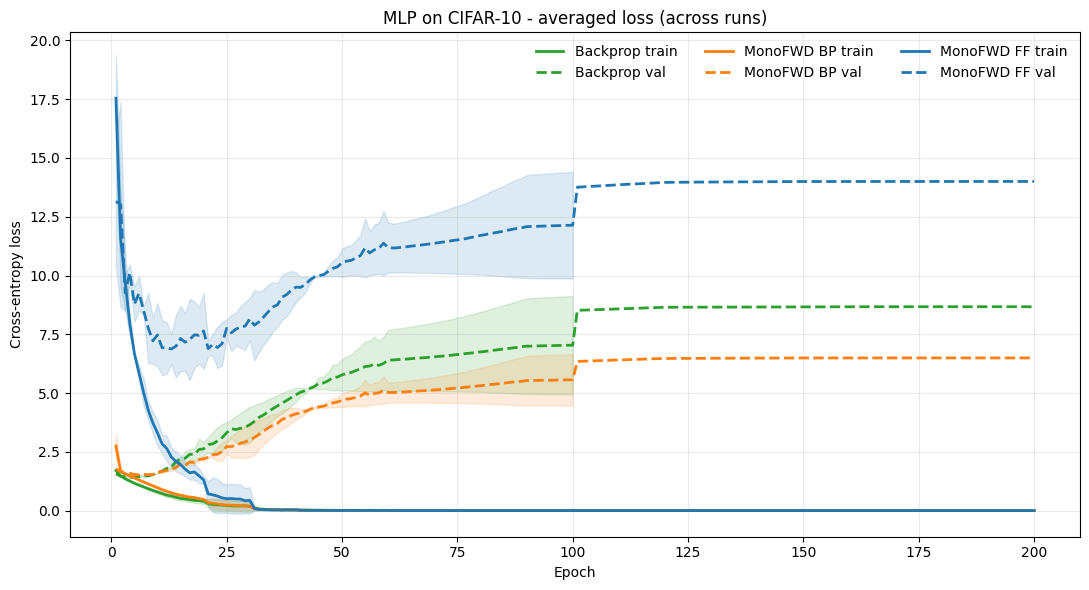

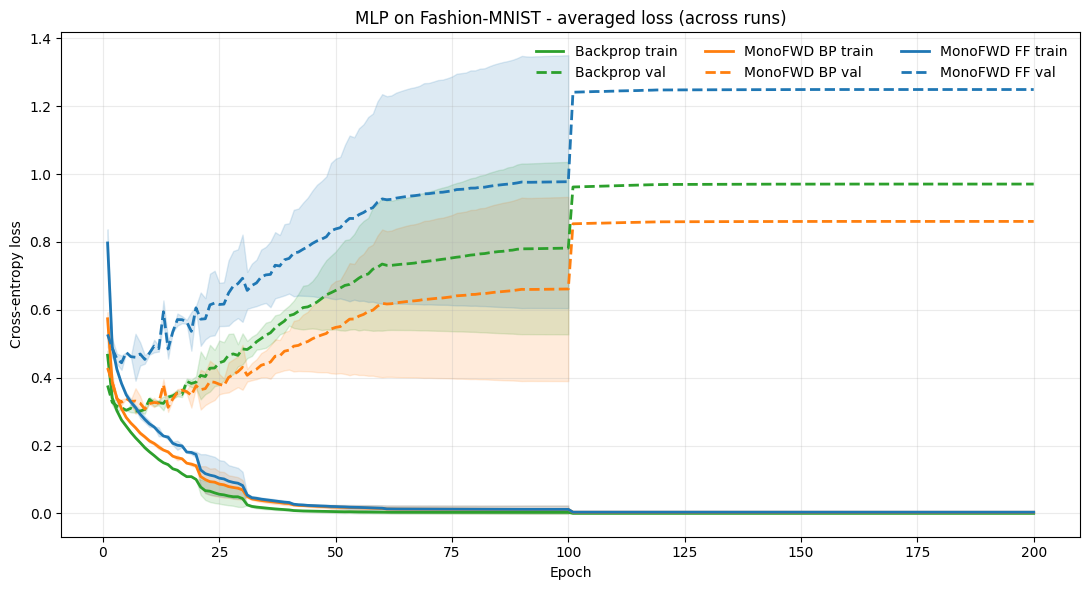

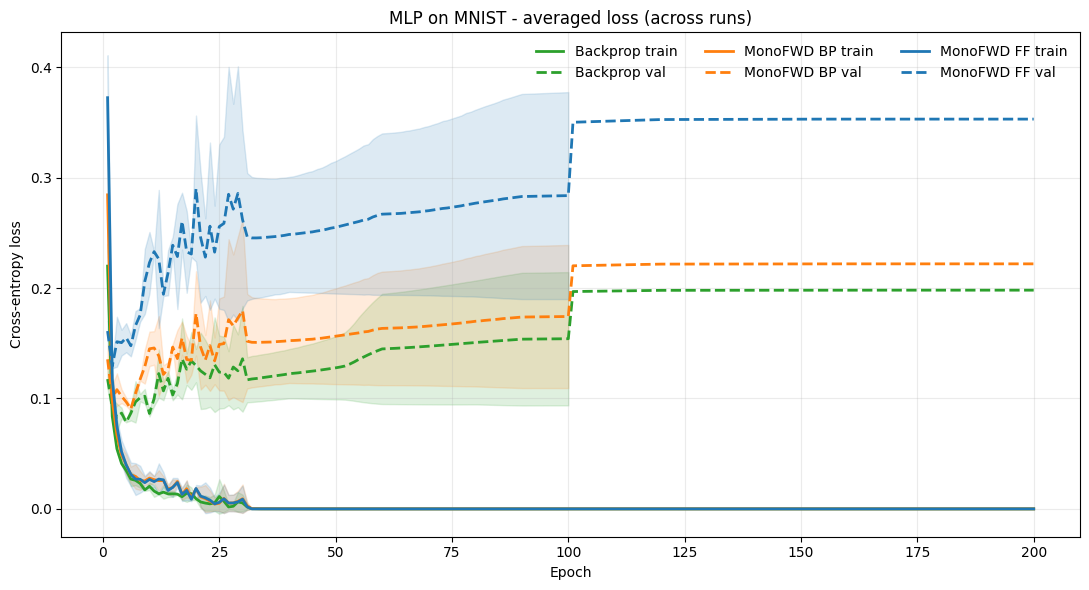

In [6]:
avg_loss_groups = avg_losses.groupby(
    ["model_label", "dataset_label"],
    sort=True,
)

for (model_label, dataset_label), model_losses in avg_loss_groups:
    fig, ax = plt.subplots(figsize=(11, 6))

    for (method_label, split), group in model_losses.groupby(
        ["method_label", "split"],
        sort=True,
    ):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value_mean"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            linewidth=2,
            label=f"{method_label} {split}",
        )

        # Add shaded region for ±1 std dev
        if group["value_std"].notna().any():
            ax.fill_between(
                group["epoch"],
                group["value_mean"] - group["value_std"],
                group["value_mean"] + group["value_std"],
                color=method_colors[method_label],
                alpha=0.15,
            )

    ax.set_title(f"{model_label} on {dataset_label} - averaged loss (across runs)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()

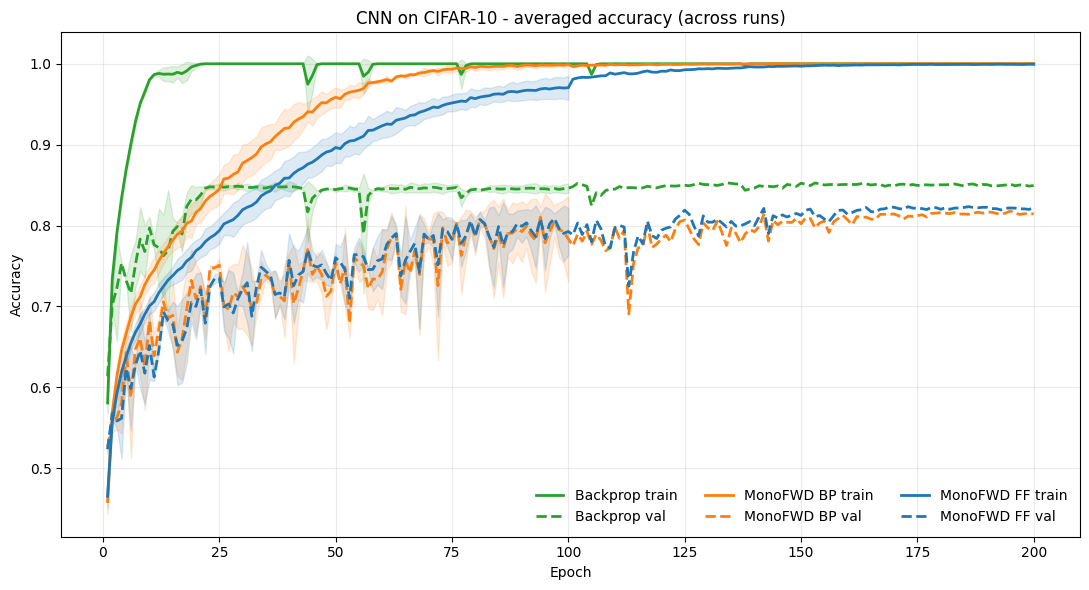

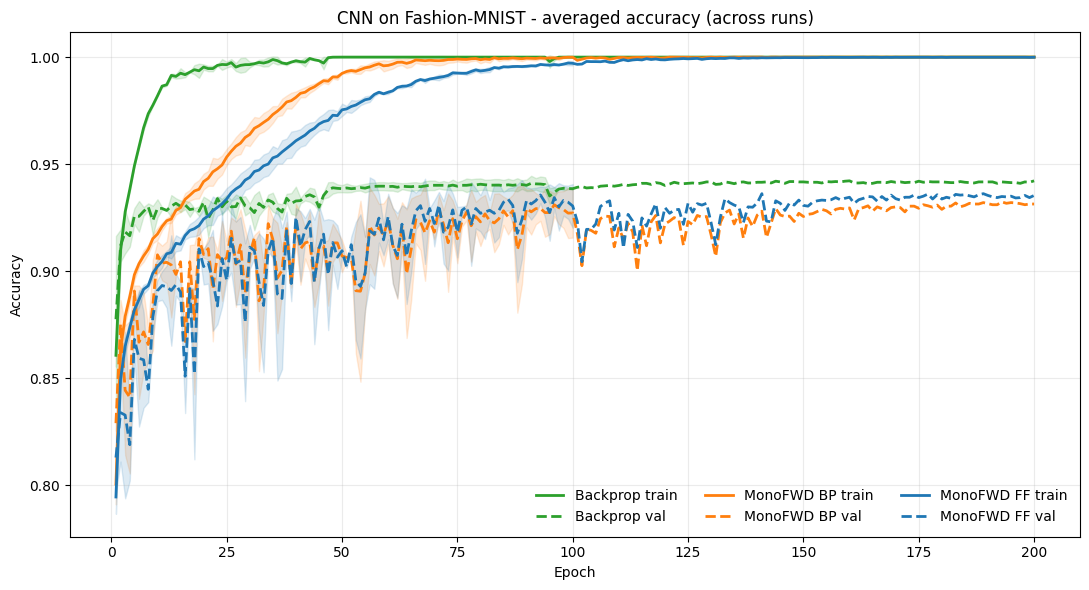

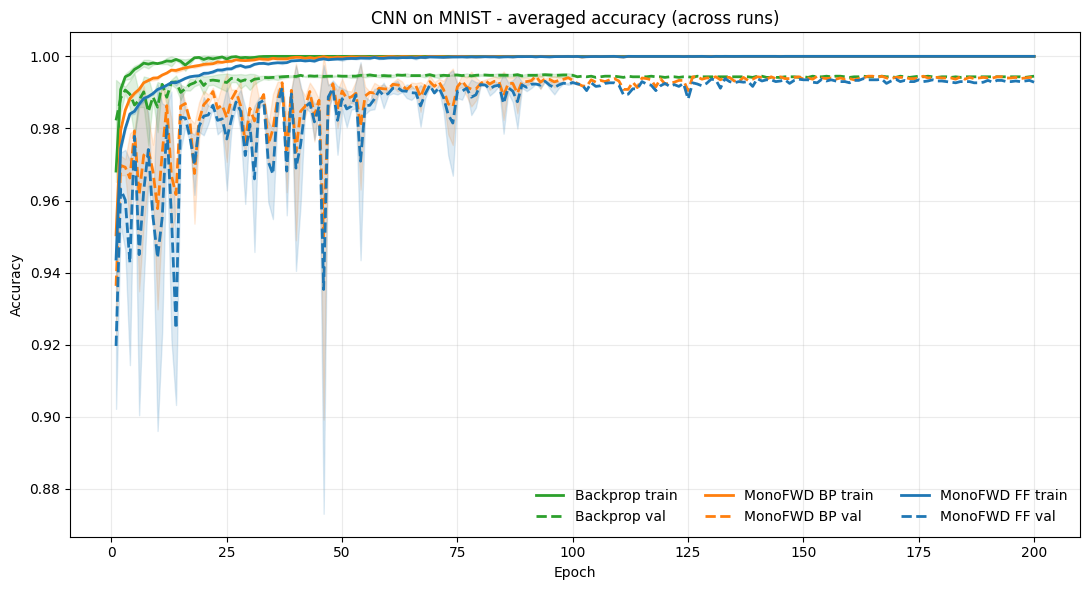

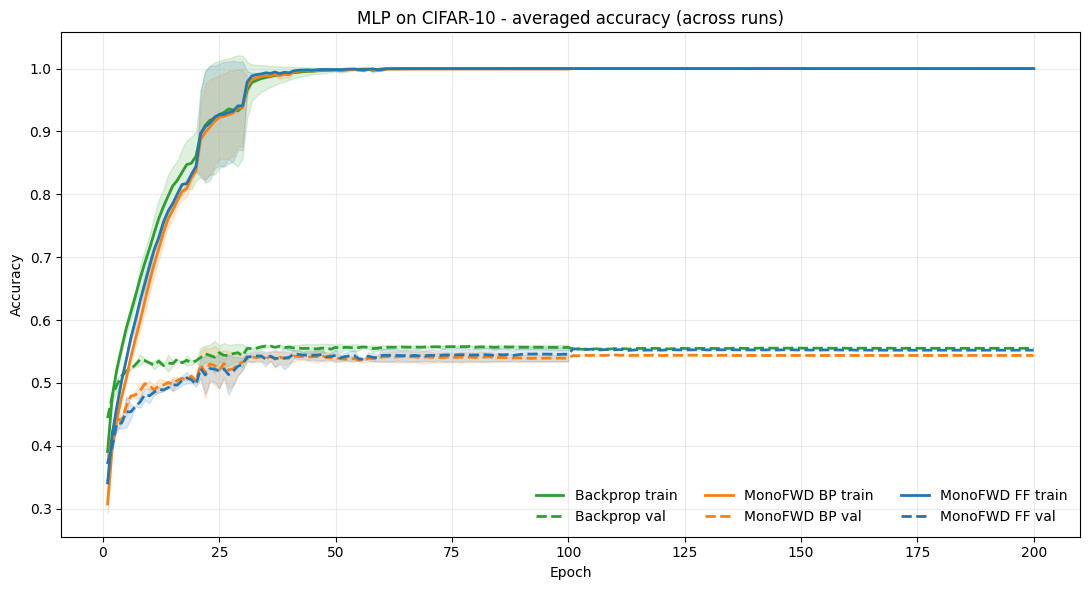

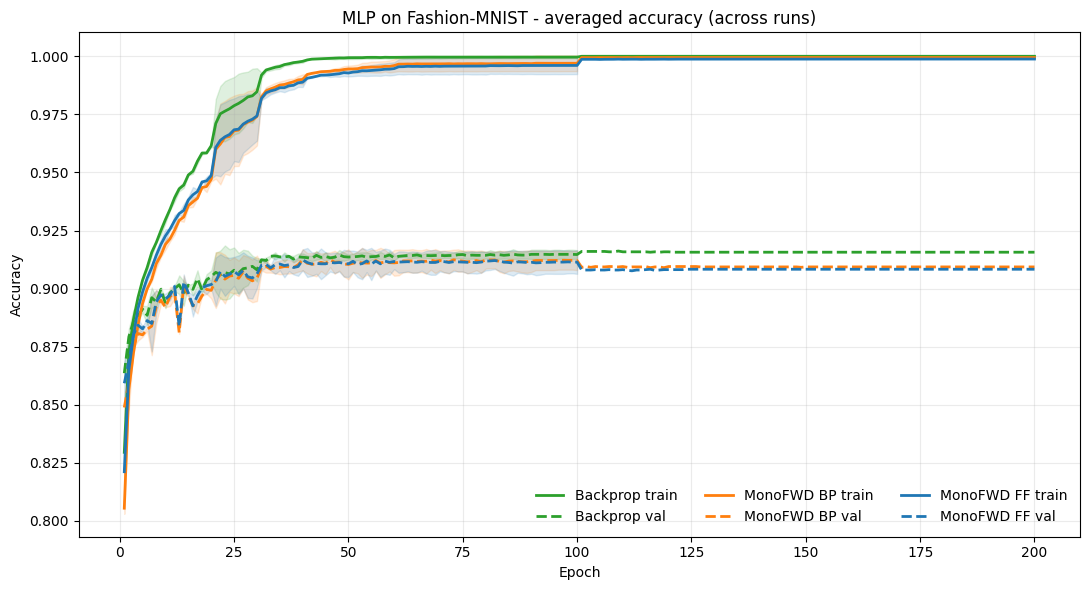

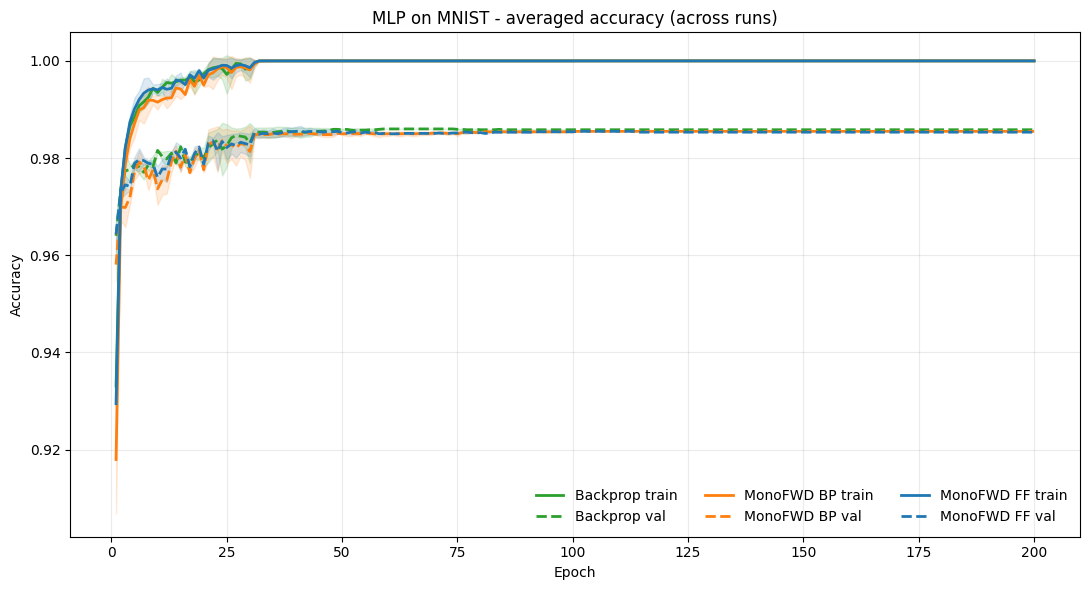

In [7]:
avg_accuracy_groups = avg_accuracies.groupby(
    ["model_label", "dataset_label"],
    sort=True,
)

for (model_label, dataset_label), model_accs in avg_accuracy_groups:
    fig, ax = plt.subplots(figsize=(11, 6))

    for (method_label, split), group in model_accs.groupby(
        ["method_label", "split"],
        sort=True,
    ):
        group = group.sort_values("epoch")
        ax.plot(
            group["epoch"],
            group["value_mean"],
            color=method_colors[method_label],
            linestyle=split_styles[split],
            linewidth=2,
            label=f"{method_label} {split}",
        )

        # Add shaded region for ±1 std dev
        if group["value_std"].notna().any():
            ax.fill_between(
                group["epoch"],
                group["value_mean"] - group["value_std"],
                group["value_mean"] + group["value_std"],
                color=method_colors[method_label],
                alpha=0.15,
            )

    ax.set_title(f"{model_label} on {dataset_label} - averaged accuracy (across runs)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()

In [ ]:
# Summary of averaged test metrics
avg_test_loss = (
    losses[losses["split"] == "test"]
    .groupby(["model_label", "dataset_label", "method_label"], as_index=False)
    .agg(
        test_loss_mean=("value", "mean"),
        test_loss_std=("value", "std"),
        count=("value", "count"),
    )
    .sort_values(["model_label", "dataset_label", "method_label"])
)

avg_test_accuracy = (
    accuracies[accuracies["split"] == "test"]
    .groupby(["model_label", "dataset_label", "method_label"], as_index=False)
    .agg(
        test_acc_mean=("value", "mean"),
        test_acc_std=("value", "std"),
        count=("value", "count"),
    )
    .sort_values(["model_label", "dataset_label", "method_label"])
)

display(
    avg_test_loss.rename(
        columns={"test_loss_mean": "loss", "test_loss_std": "loss_std"}
    )
)
display(
    avg_test_accuracy.rename(
        columns={"test_acc_mean": "accuracy", "test_acc_std": "accuracy_std"}
    )
)

,model_label,dataset_label,method_label,loss,loss_std,count
0,CNN,CIFAR-10,Backprop,1.102066,0.128416,2
1,CNN,CIFAR-10,MonoFWD BP,1.004041,0.369400,2
2,CNN,CIFAR-10,MonoFWD FF,1.595639,0.485243,2
3,CNN,Fashion-MNIST,Backprop,0.711446,0.210783,2
4,CNN,Fashion-MNIST,MonoFWD BP,0.598423,0.200664,2
5,CNN,Fashion-MNIST,MonoFWD FF,0.899053,0.288019,2
6,CNN,MNIST,Backprop,0.032584,0.010304,2
7,CNN,MNIST,MonoFWD BP,0.048200,0.007396,2
8,CNN,MNIST,MonoFWD FF,0.095557,0.011740,2
9,MLP,CIFAR-10,Backprop,6.956161,2.170525,2


,model_label,dataset_label,method_label,accuracy,accuracy_std,count
0,CNN,CIFAR-10,Backprop,0.83715,0.002758,2
1,CNN,CIFAR-10,MonoFWD BP,0.80850,0.003394,2
2,CNN,CIFAR-10,MonoFWD FF,0.81260,0.003536,2
3,CNN,Fashion-MNIST,Backprop,0.93125,0.000778,2
4,CNN,Fashion-MNIST,MonoFWD BP,0.92100,0.001697,2
5,CNN,Fashion-MNIST,MonoFWD FF,0.92360,0.001697,2
6,CNN,MNIST,Backprop,0.99530,0.000141,2
7,CNN,MNIST,MonoFWD BP,0.99240,0.000283,2
8,CNN,MNIST,MonoFWD FF,0.99180,0.000424,2
9,MLP,CIFAR-10,Backprop,0.55435,0.004596,2


: 